Imports


In [74]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from datetime import datetime
from datetime import date

%matplotlib inline

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_PATH = "Data/"  
clients = pd.read_csv(DATA_PATH+"train_info.csv")

Imports


Première visualisation des données


In [75]:
display(clients.head(10))

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client
0,1,male,44,1,28.0,0,> 2 ans,oui,40454.0,26.0,217,1
1,2,male,76,1,3.0,0,1-2 an,no,33536.0,26.0,183,0
2,3,male,47,1,28.0,0,> 2 ans,oui,38294.0,26.0,27,1
3,4,male,21,1,11.0,1,< 1 an,no,28619.0,152.0,203,0
4,5,femelle,29,1,41.0,1,< 1 an,no,27496.0,152.0,39,0
5,6,femelle,24,1,33.0,0,< 1 an,oui,2630.0,160.0,176,0
6,7,male,23,1,11.0,0,< 1 an,oui,23367.0,152.0,249,0
7,8,femelle,56,1,28.0,0,1-2 an,oui,32031.0,26.0,72,1
8,9,femelle,24,1,3.0,1,< 1 an,no,27619.0,152.0,28,0
9,10,femelle,32,1,6.0,1,< 1 an,no,28771.0,152.0,80,0


Résumé du jeu de données et typologie des variables : Commencez par obtenir une vue d’ensemble
du dataset (dimensions, types de variables, statistiques descriptives). Il s’agit notamment d’identifier
les variables quantitatives et catégorielles, ainsi que de détecter d’éventuels problèmes tels que des
valeurs manquantes ou des valeurs aberrantes


In [93]:
def clients_shape(clients):
    return clients.shape
def clients_type(clients):
    return clients.info()
def clients_valeur_manquantes(clients):
    return clients[clients.isnull().sum(axis=1) > 0].copy()
def clients_duplicated_values(clients):
    return clients[clients.duplicated()]
def clients_stats(clients):
    return clients.describe(include='all')
def clients_categorielles(clients):
    cat_vars = clients.select_dtypes(include=['object']).columns.tolist()
    if 'permis_conduire' in clients.columns:
        cat_vars.append('permis_conduire')
    return cat_vars

In [94]:
display(clients_shape(clients))
display(clients_type(clients))
display(clients_valeur_manquantes(clients))
display(clients_duplicated_values(clients))

(381109, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id_client            381109 non-null  int64  
 1   genre                381109 non-null  object 
 2   age                  381109 non-null  int64  
 3   permis_conduire      381109 non-null  int64  
 4   code_regional        381109 non-null  float64
 5   ancien_assure        381109 non-null  int64  
 6   age_vehicule         381109 non-null  object 
 7   vehicule_endommage   381109 non-null  object 
 8   prime_annuelle       381109 non-null  float64
 9   canal_communication  381109 non-null  float64
 10  anciennete           381109 non-null  int64  
 11  reponse_client       381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


None

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client


,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client


In [95]:
display(clients_stats(clients))
display(clients_categorielles(clients))

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client
count,381109.000000,381109,381109.000000,381109.000000,381109.000000,381109.000000,381109,381109,381109.000000,381109.000000,381109.000000,381109.000000
unique,NaN,2,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN,NaN
top,NaN,male,NaN,NaN,NaN,NaN,1-2 an,oui,NaN,NaN,NaN,NaN
freq,NaN,206089,NaN,NaN,NaN,NaN,200316,192413,NaN,NaN,NaN,NaN
mean,190555.000000,NaN,38.822584,0.997869,26.388807,0.458210,NaN,NaN,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,NaN,15.511611,0.046110,13.229888,0.498251,NaN,NaN,17213.155057,54.203995,83.671304,0.327936
min,1.000000,NaN,20.000000,0.000000,0.000000,0.000000,NaN,NaN,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,NaN,25.000000,1.000000,15.000000,0.000000,NaN,NaN,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,NaN,36.000000,1.000000,28.000000,0.000000,NaN,NaN,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,NaN,49.000000,1.000000,35.000000,1.000000,NaN,NaN,39400.000000,152.000000,227.000000,0.000000


['genre', 'age_vehicule', 'vehicule_endommage', 'permis_conduire']

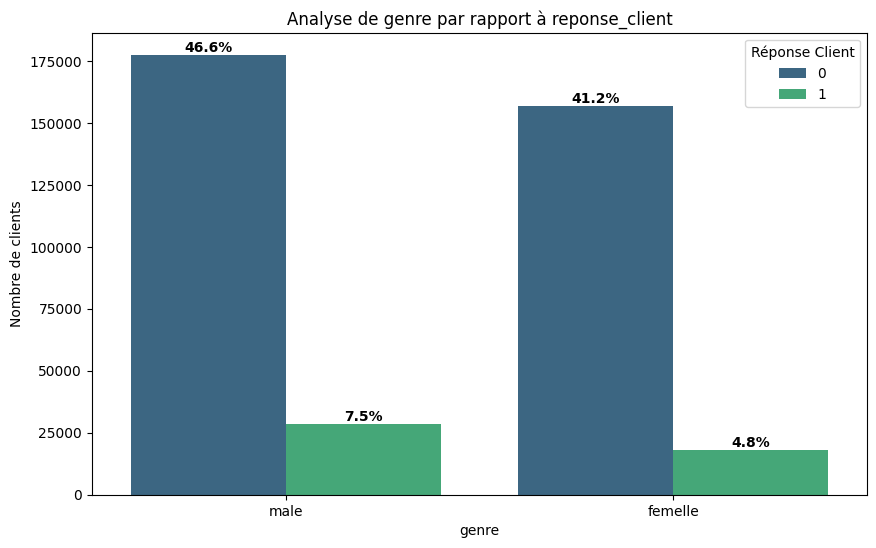

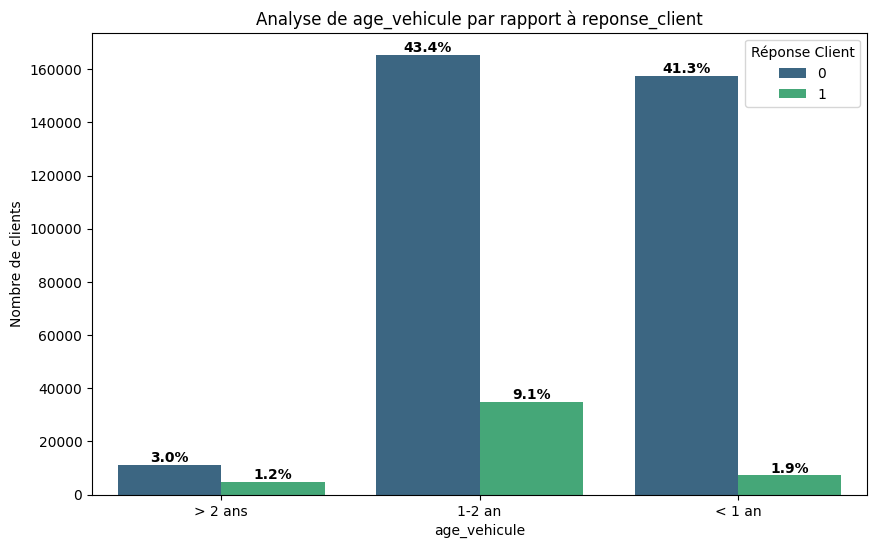

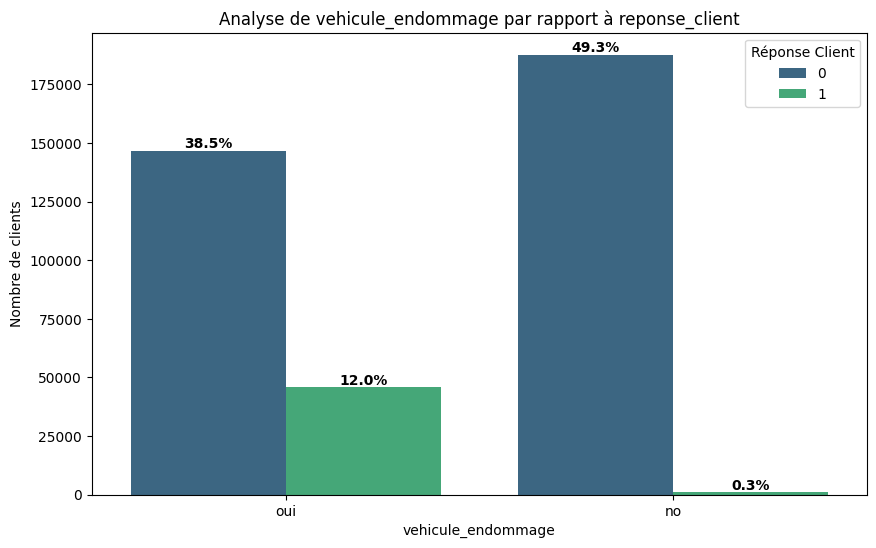

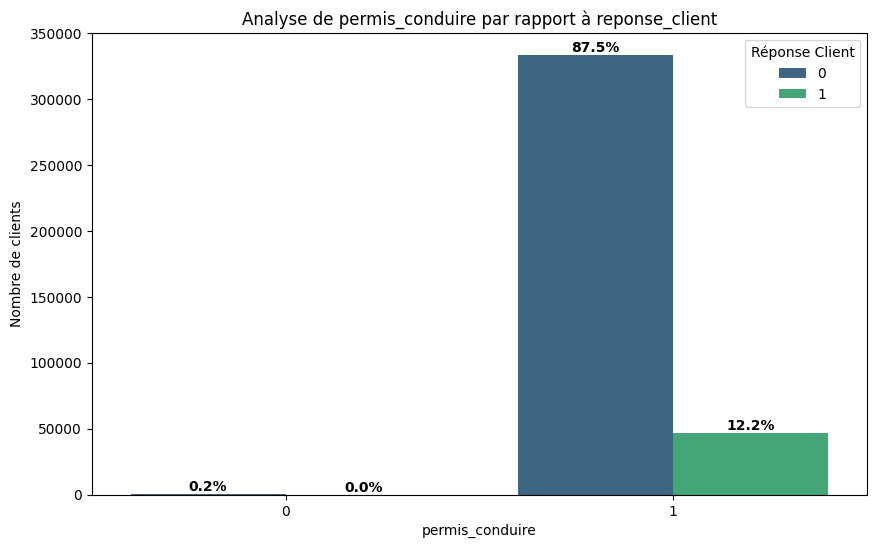

In [97]:
def plot_cat_vs_target(df, col_categorielle, target='reponse_client'):
    plt.figure(figsize=(10, 6))
    
    ax = sns.countplot(data=df, x=col_categorielle, hue=target, palette='viridis')
    
    plt.title(f"Analyse de {col_categorielle} par rapport à {target}")
    plt.xlabel(col_categorielle)
    plt.ylabel("Nombre de clients")
    
    total_height = len(df)
    
    # Ajout des pourcentages uniquement sur les barres réelles
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # <--- Le correctif est ici !
            percentage = f'{100 * height / total_height:.1f}%'
            x = p.get_x() + p.get_width() / 2
            y = height
            ax.annotate(percentage, (x, y), 
                        ha='center', va='bottom', 
                        fontsize=10, fontweight='bold')
    
    plt.legend(title="Réponse Client", loc='upper right')
    plt.show()
for col in clients_categorielles(clients):
    plot_cat_vs_target(clients, col)